In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import tensorflow as tf

train_ds_1 = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/archive/train',
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/archive/valid',
    image_size=(128, 128),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/archive/test',
    image_size=(128, 128),
    batch_size=32
)

Found 12594 files belonging to 100 classes.
Found 500 files belonging to 100 classes.
Found 500 files belonging to 100 classes.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = '/content/drive/MyDrive/Colab Notebooks/archive/butterflies and moths.csv'
df = pd.read_csv(csv_path)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13594 entries, 0 to 13593
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   class id   13594 non-null  int64 
 1   filepaths  13594 non-null  object
 2   labels     13594 non-null  object
 3   data set   13594 non-null  object
dtypes: int64(1), object(3)
memory usage: 424.9+ KB


In [ ]:
df["data set"]

,data set
0,train
1,train
2,train
3,train
4,train
...,...
13589,valid
13590,valid
13591,valid
13592,valid


In [ ]:
# Create the table
species_distribution = pd.crosstab(df['labels'], df['data set'])

# Display the first few rows to verify
print(species_distribution)

data set                   test  train  valid
labels                                       
ADONIS                        5    126      5
AFRICAN GIANT SWALLOWTAIL     5    107      5
AMERICAN SNOOT                5    105      5
AN 88                         5    121      5
APPOLLO                       5    128      5
...                         ...    ...    ...
VICEROY                       5    115      5
WHITE LINED SPHINX MOTH       5    143      5
WOOD SATYR                    5    102      5
YELLOW SWALLOW TAIL           5    107      5
ZEBRA LONG WING               5    104      5

[100 rows x 3 columns]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files # Required for the download step

# --- 1. Load the Data and Create the Cross-Tabulation ---
csv_path = '/content/drive/MyDrive/Colab Notebooks/archive/butterflies and moths.csv'
df = pd.read_csv(csv_path)

# Create the summary table
species_distribution = pd.crosstab(df['labels'], df['data set'])

# Get the first 10 rows (including all dataset splits: test, train, valid)
top_10_dist = species_distribution.head(10)

# --- 2. Render the Table using Matplotlib ---
# We set up a figure without the standard chart axes
fig, ax = plt.subplots(figsize=(10, 4)) # Adjust figsize as needed
ax.axis('off') # Hide the main chart border and ticks

# Create the visual table
table = ax.table(
    cellText=top_10_dist.values,
    colLabels=top_10_dist.columns,
    rowLabels=top_10_dist.index,
    loc='center',
    cellLoc='center'
)

# Optional styling: scale the table so it fills the figure area
table.scale(1.2, 1.8)

# --- 3. Save the Table as an Image ---
output_filename = 'species_distribution_top10.png'
plt.savefig(output_filename, bbox_inches='tight', dpi=300)
plt.close(fig) # Close the figure to free up memory

# --- 4. Download the Image ---
#files.download(output_filename)

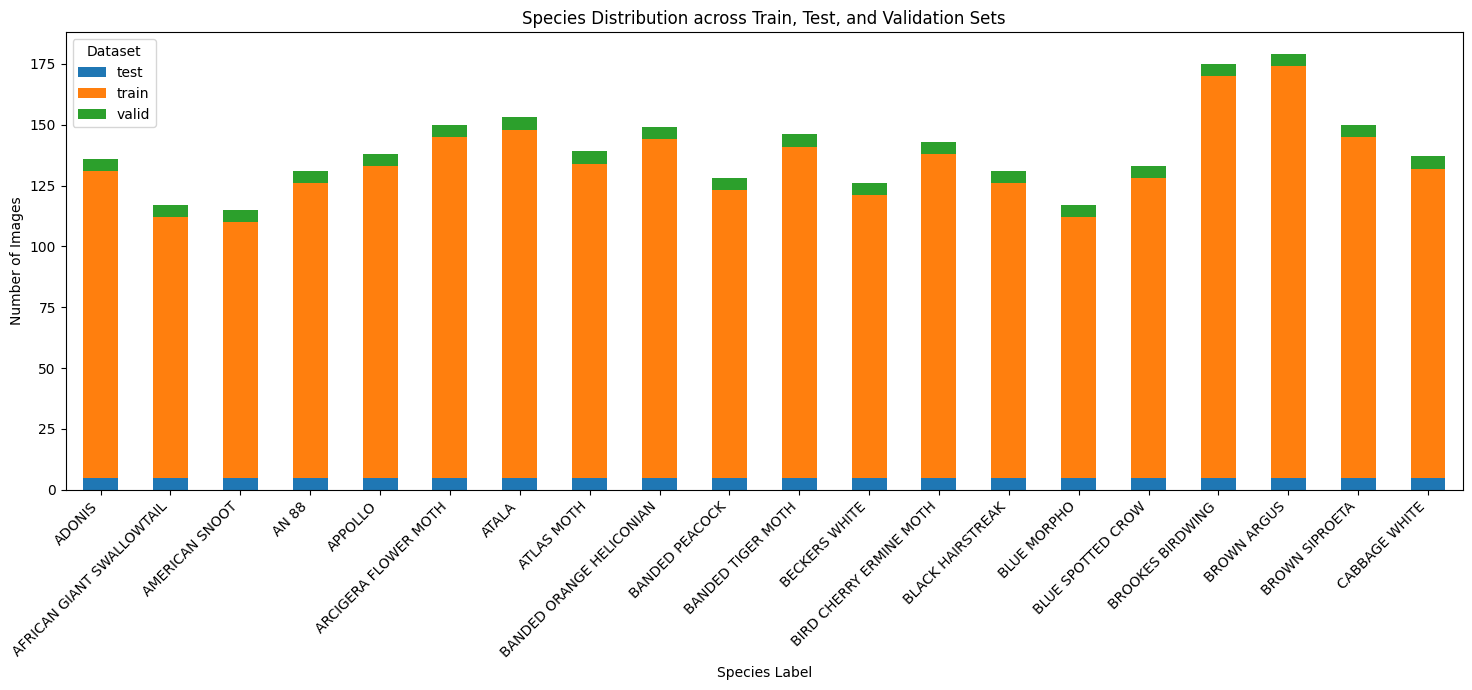

In [ ]:
# Plotting the distribution for the first 20 species as an example
species_distribution.head(20).plot(kind='bar', figsize=(15, 7), stacked=True)

plt.title('Species Distribution across Train, Test, and Validation Sets')
plt.xlabel('Species Label')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

In [ ]:
class_names = train_ds_1.class_names
print(class_names)

['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO', 'ARCIGERA FLOWER MOTH', 'ATALA', 'ATLAS MOTH', 'BANDED ORANGE HELICONIAN', 'BANDED PEACOCK', 'BANDED TIGER MOTH', 'BECKERS WHITE', 'BIRD CHERRY ERMINE MOTH', 'BLACK HAIRSTREAK', 'BLUE MORPHO', 'BLUE SPOTTED CROW', 'BROOKES BIRDWING', 'BROWN ARGUS', 'BROWN SIPROETA', 'CABBAGE WHITE', 'CAIRNS BIRDWING', 'CHALK HILL BLUE', 'CHECQUERED SKIPPER', 'CHESTNUT', 'CINNABAR MOTH', 'CLEARWING MOTH', 'CLEOPATRA', 'CLODIUS PARNASSIAN', 'CLOUDED SULPHUR', 'COMET MOTH', 'COMMON BANDED AWL', 'COMMON WOOD-NYMPH', 'COPPER TAIL', 'CRECENT', 'CRIMSON PATCH', 'DANAID EGGFLY', 'EASTERN COMA', 'EASTERN DAPPLE WHITE', 'EASTERN PINE ELFIN', 'ELBOWED PIERROT', 'EMPEROR GUM MOTH', 'GARDEN TIGER MOTH', 'GIANT LEOPARD MOTH', 'GLITTERING SAPPHIRE', 'GOLD BANDED', 'GREAT EGGFLY', 'GREAT JAY', 'GREEN CELLED CATTLEHEART', 'GREEN HAIRSTREAK', 'GREY HAIRSTREAK', 'HERCULES MOTH', 'HUMMING BIRD HAWK MOTH', 'INDRA SWALLOW', 'IO MOTH', 'Iphiclus si

We have 12594 observations of moths and butterflies, with 100 different species in our training dataset.

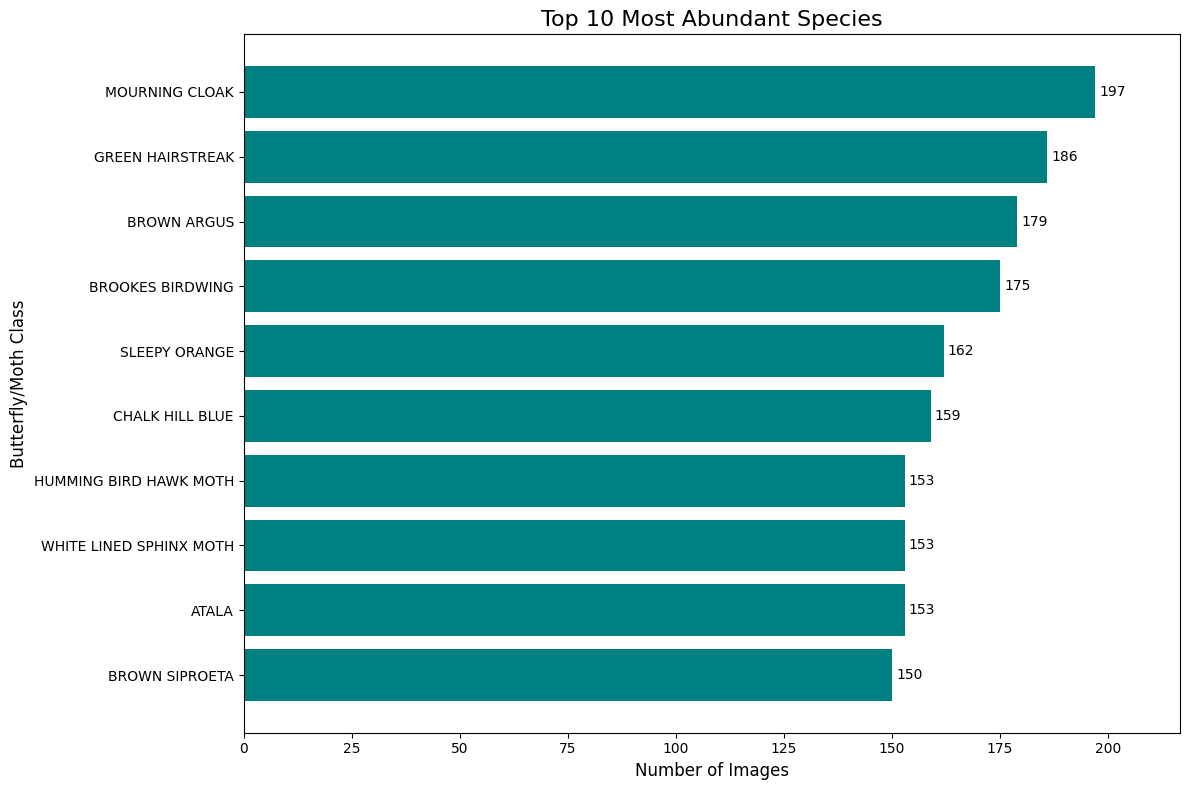

In [ ]:
import matplotlib.pyplot as plt

# 1. Get only the top 10 most abundant species
class_counts = df['labels'].value_counts().head(10)

names = class_counts.index
values = class_counts.values

# 2. Create the plot
fig, ax = plt.subplots(figsize=(12, 8)) # Adjusted height for only 10 rows
bars = ax.barh(names, values, color='teal')

# Add the counts at the end of the bars
ax.bar_label(bars, padding=3)

# Formatting
ax.set_xlabel('Number of Images', fontsize=12)
ax.set_ylabel('Butterfly/Moth Class', fontsize=12)
ax.set_title('Top 10 Most Abundant Species', fontsize=16)
ax.invert_yaxis()  # Put the most abundant at the top
ax.set_xlim(0, max(values) * 1.1)

plt.tight_layout()
plt.show()

We have 100 categories of moths and butterflys, each with at least 100 images. The most abundant categories are Morning Cloak, Green Hairstreak, Brown Argus, and Brook Birdwing.

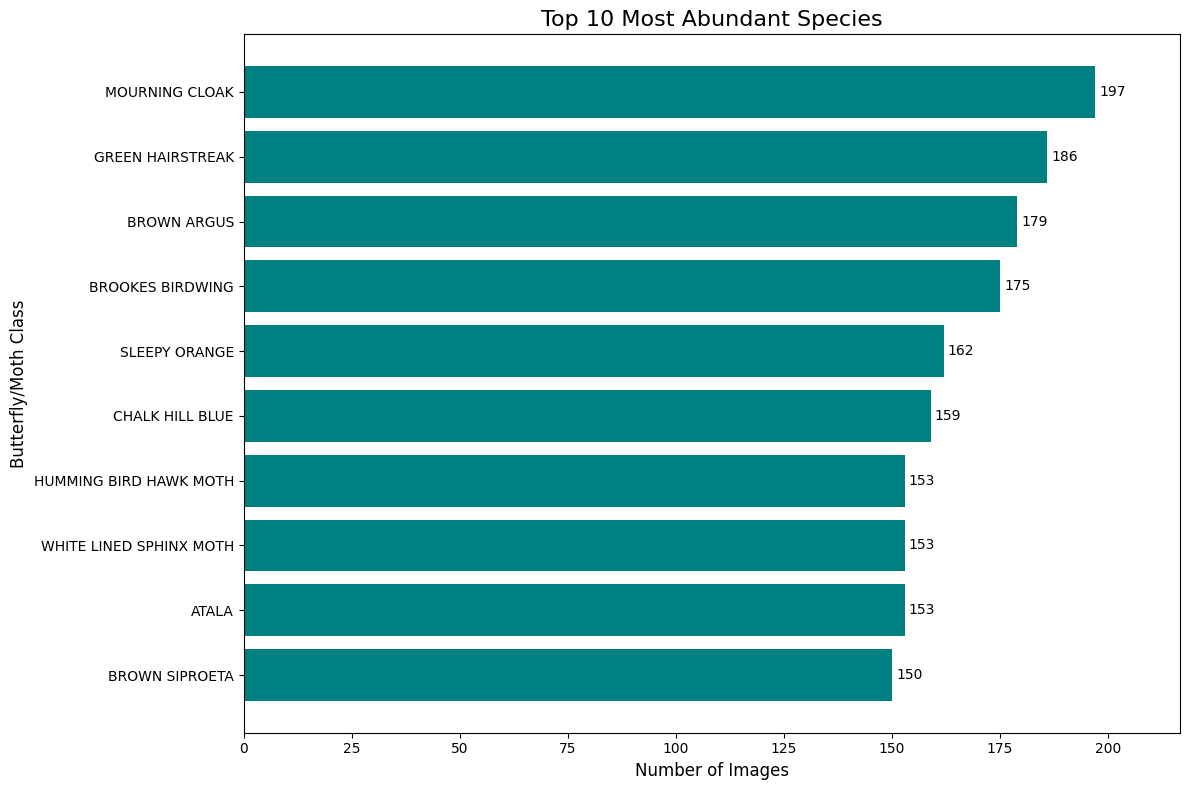

In [ ]:
import matplotlib.pyplot as plt

# 1. Get only the top 10 most abundant species
class_counts = df['labels'].value_counts().head(10)

names = class_counts.index
values = class_counts.values

# 2. Create the plot
fig, ax = plt.subplots(figsize=(12, 8)) # Adjusted height for only 10 rows
bars = ax.barh(names, values, color='teal')

# Add the counts at the end of the bars
ax.bar_label(bars, padding=3)

# Formatting
ax.set_xlabel('Number of Images', fontsize=12)
ax.set_ylabel('Butterfly/Moth Class', fontsize=12)
ax.set_title('Top 10 Most Abundant Species', fontsize=16)
ax.invert_yaxis()  # Put the most abundant at the top
ax.set_xlim(0, max(values) * 1.1)

plt.tight_layout()
plt.show()

In [ ]:
# base_path  = '/content/drive/MyDrive/Colab Notebooks/archive/'
# BATCH_SIZE = 32
# IMG_SIZE   = (224, 224)

# # Load train and val in one call using a workaround
# import numpy as np

# full_ds = tf.keras.utils.image_dataset_from_directory(
#     base_path + 'train',
#     image_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     shuffle=True,
#     seed=42
# )

# class_names = full_ds.class_names
# num_classes = len(class_names)
# print(f'Number of classes: {num_classes}')

# # Manually split 80/20
# total_batches = len(full_ds)
# train_size    = int(0.8 * total_batches)

# train_ds_raw = full_ds.take(train_size)
# val_ds_raw   = full_ds.skip(train_size)

# print(f'Train batches: {train_size}')
# print(f'Val batches:   {total_batches - train_size}')

# # Test set stays separate
# test_ds_raw = tf.keras.utils.image_dataset_from_directory(
#     base_path + 'test',
#     image_size=IMG_SIZE,
#     batch_size=BATCH_SIZE
# )



In [ ]:
base_path  = '/content/drive/MyDrive/Colab Notebooks/archive/'
BATCH_SIZE = 32
IMG_SIZE   = (224, 224)

# Load train and val in one call using a workaround
import numpy as np
# 1. Load the full raw dataset
full_ds_raw = tf.keras.utils.image_dataset_from_directory(
    base_path + 'train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# 2. Limit to a specific number of samples (e.g., 500 images)
# Since .take() works on batches, calculate how many batches equal ~500 images
subset_size_images = 2500
subset_batches = subset_size_images // BATCH_SIZE

# Create the smaller subset
small_ds = full_ds_raw.take(subset_batches)

# 3. Split this subset into Train and Val (80/20)
train_size = int(0.8 * subset_batches)

train_ds_raw = small_ds.take(train_size)
val_ds_raw   = small_ds.skip(train_size)

print(f'New Train batches: {train_size} (~{train_size * BATCH_SIZE} images)')
print(f'New Val batches:   {subset_batches - train_size}')
# Test set stays separate
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    base_path + 'test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 12594 files belonging to 100 classes.
New Train batches: 62 (~1984 images)
New Val batches:   16
Found 500 files belonging to 100 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)
test_ds  = test_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomFlip('vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
], name='augmentation')

In [ ]:
model = models.Sequential([
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    # Block 5
    layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(0.005)),
    layers.Dropout(0.6),
    layers.Dense(subset_size_images, activation='softmax')
])

model.build(input_shape=(None, 224, 224, 3))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2500)           │       642,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,346,372 (8.95 MB)

 Trainable params: 2,344,388 (8.94 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 34s 270ms/step - accuracy: 0.0186 - loss: 8.9899 - val_accuracy: 0.0137 - val_loss: 9.2966 - learning_rate: 1.0000e-04
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - accuracy: 0.0625 - loss: 7.1852 - val_accuracy: 0.0137 - val_loss: 8.7408 - learning_rate: 1.0000e-04
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.0761 - loss: 6.0567 - val_accuracy: 0.0137 - val_loss: 7.7486 - learning_rate: 1.0000e-04
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.1079 - loss: 5.6485 - val_accuracy: 0.0137 - val_loss: 6.8861 - learning_rate: 1.0000e-04
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.1225 - loss: 5.3811 - val_accuracy: 0.0215 - val_loss: 6.5520 - learning_rate: 1.0000e-04
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.1492 - loss: 5.1814 - val_accuracy: 0.0195 - val_loss: 6.3220 - learning_rate: 1.0000e-04
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy:

In [ ]:
#evaluate on the dataset
print('\n=== TEST SET EVALUATION ===')
test_loss, test_acc = model.evaluate(test_ds)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss:     {test_loss:.4f}')


=== TEST SET EVALUATION ===
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.3620 - loss: 3.5228
Test accuracy: 0.3620
Test loss:     3.5228


In [ ]:
save_path = base_path + 'pollinator_model.keras'
model.save(save_path)
print(f'Model saved to: {save_path}')

Model saved to: /content/drive/MyDrive/Colab Notebooks/archive/pollinator_model.keras


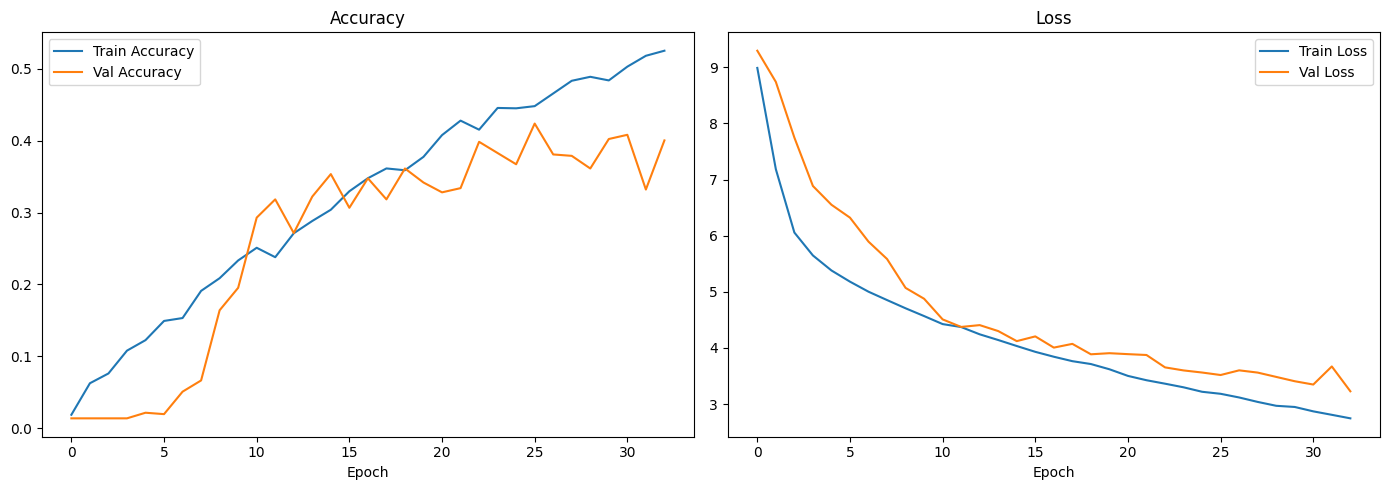

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig(base_path + 'training_history.png')
plt.show()


--- TOP 10 COMMON MIX-UPS ---
Actual                Predicted             
CAIRNS BIRDWING       MADAGASCAN SUNSET MOTH    4
GREAT EGGFLY          BROWN SIPROETA            4
EASTERN DAPPLE WHITE  LARGE MARBLE              4
QUESTION MARK         EASTERN COMA              4
ZEBRA LONG WING       GARDEN TIGER MOTH         4
CHALK HILL BLUE       ADONIS                    3
GOLD BANDED           SILVER SPOT SKIPPER       3
TWO BARRED FLASHER    BROWN SIPROETA            3
PIPEVINE SWALLOW      RED SPOTTED PURPLE        3
POPINJAY              RED SPOTTED PURPLE        3
Name: count, dtype: int64


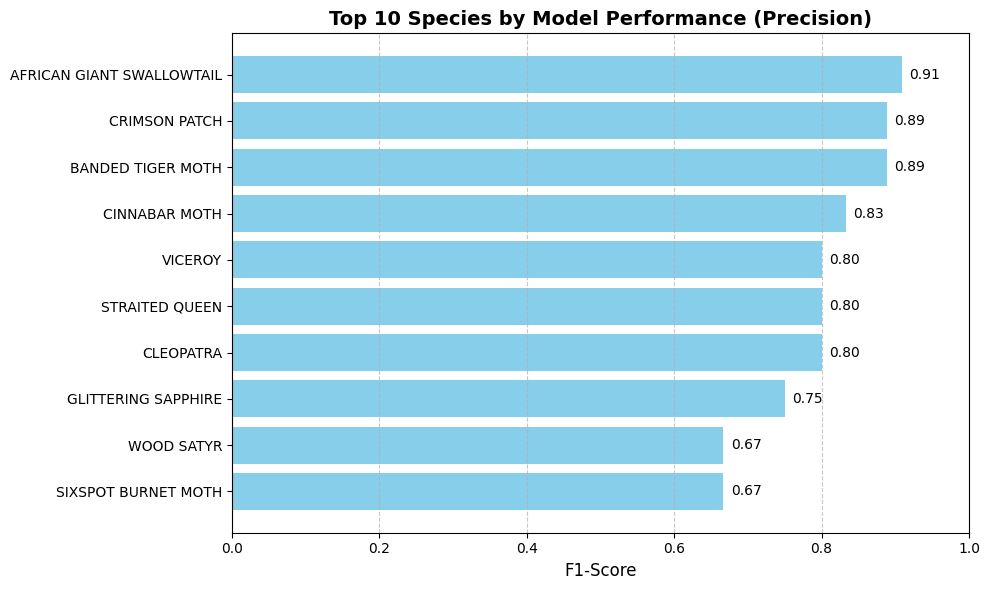

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


train_ds_1 = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/pollinators/train',
    image_size=(128, 128),
    batch_size=32
)
class_names = train_ds_1.class_names
print(class_names)

# Generate the report as a dictionary
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Convert to a list of (species, f1-score) and sort it
# We use F1-score because it balances precision and recall
species_performance = []
for species in class_names:
    score = report[species]['f1-score']
    species_performance.append((species, score))

# Sort by score (ascending)
species_performance.sort(key=lambda x: x[1])

# Extract the top 10 species from your sorted list
# Since species_performance is sorted ascending, the best are at the end
best_10 = species_performance[-10:]

# Separate names and scores for plotting
names = [x[0] for x in best_10]
scores = [x[1] for x in best_10]

# Create the plot
plt.figure(figsize=(10, 6))
bars = plt.barh(names, scores, color='skyblue')

# Add styling
plt.xlabel('F1-Score', fontsize=12)
plt.title('Top 10 Species by Model Performance (Precision)', fontsize=14, fontweight='bold')
plt.xlim(0, 1.0)  # F1-score is always between 0 and 1
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add the actual score labels on the bars for precision
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center')

plt.tight_layout()
plt.show()

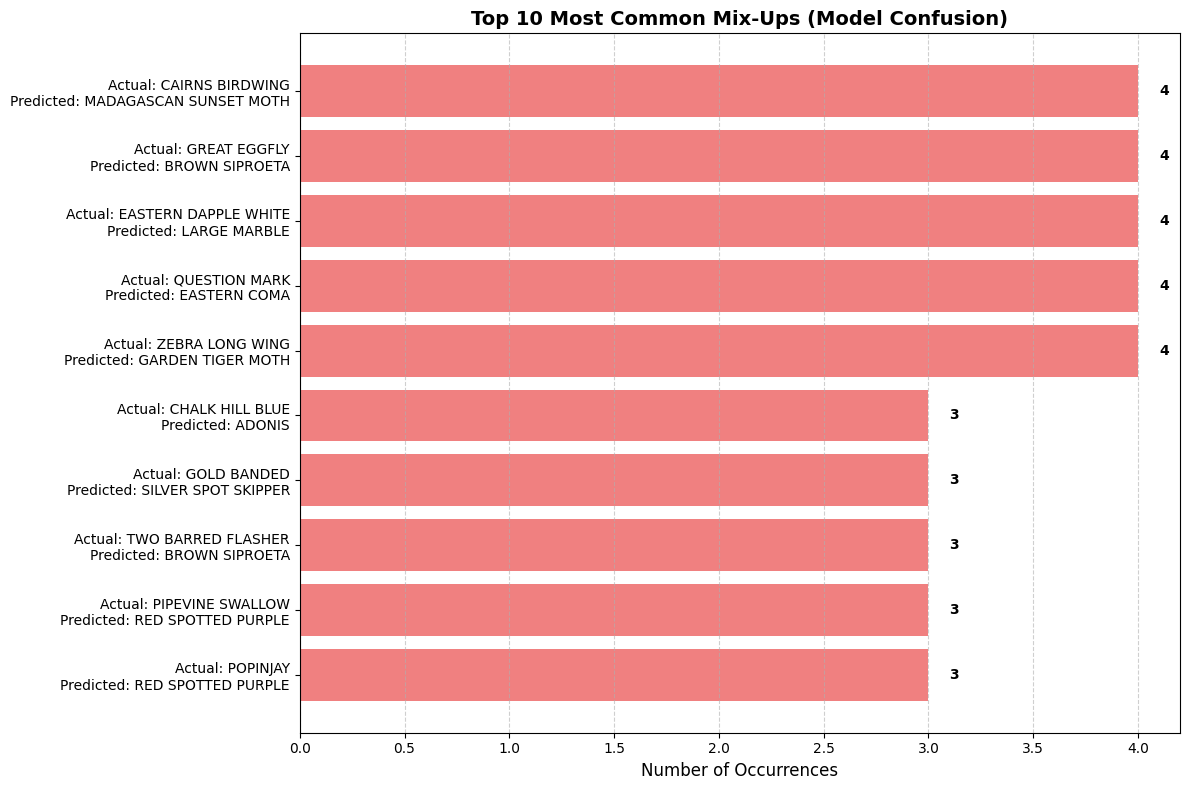

In [ ]:
import matplotlib.pyplot as plt


import pandas as pd

# Create a DataFrame of mistakes
mistakes = pd.DataFrame({'Actual': y_true, 'Predicted': y_pred})
mistakes = mistakes[mistakes['Actual'] != mistakes['Predicted']]

# Map numbers back to species names
mistakes['Actual'] = mistakes['Actual'].map(lambda x: class_names[x])
mistakes['Predicted'] = mistakes['Predicted'].map(lambda x: class_names[x])

# Get the top 10 mix-ups and their counts
# We use value_counts() on the 'mistakes' DataFrame created in your snippet
top_mixups = mistakes.value_counts().head(10)

# Prepare labels and values for the chart
# The index of top_mixups contains tuples like ('Actual Name', 'Predicted Name')
mixup_labels = [f"Actual: {a}\nPredicted: {p}" for a, p in top_mixups.index]
counts = top_mixups.values

# Create the plot
plt.figure(figsize=(12, 8))
bars = plt.barh(mixup_labels, counts, color='lightcoral')

# Add styling
plt.xlabel('Number of Occurrences', fontsize=12)
plt.title('Top 10 Most Common Mix-Ups (Model Confusion)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Put the most common mix-up at the top
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Add count labels to the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()